# Acquisition test bench

Notebook to **exercise every plot type** (single plots and full grids, all $g^{(2)}$ methods and the
Cauchy–Schwarz $R$) on a freshly acquired file .

In [1]:
import numpy as np
from pathlib import Path
from src.hbt_core import HBTMeasurement
from src.hbt_visu import GridVisualizer

## 1. Load & inspect the raw file

In [2]:
PKL = Path("data/Jun15/test.pkl")
run = HBTMeasurement(PKL)
run.describe(max_depth=4)

PKL FILE : test.pkl
FOLDER   : Jun15
top-level keys: ['Parameters', 'data']
Parameters/  (dict, 2 keys)
    general/  (dict, 8 keys)
        date: str = '2026-06-15'
        time: str = '16-04-26'
        experiment_type: str = 'g2_heralded_virtual'
        save_dir: str = 'C:\\Users\\QUANTUM\\OneDrive - ENSTA\\!Working files\\HBT\\HBT Data\\Tests_Jun\\2026-06-15_16-04-26_g2_heralded_virtual'
        material: str = 'CdTe110'
        laser/  (dict, 2 keys)
            rep_rate_hz: float = 18880000.0
            wavelength_nm: int = 2100
        timetagging/  (dict, 10 keys)
            tt_mode: str = 'Standard'
            binwidth_ps: int = 100
            num_bins: int = 50000
            channels: list[6]  (1, 2, 3, 4, ...)
            mode_on_channel: list[6]  (H3T, H3R, H4T, H4R, ...)
            deadtime: list[6]  (0, 0, 0, 0, ...)
            delays: list[6]  (0, -1000, 20000, 16500, ...)
            coincidence_window: int = 25000
            trigger: list[0]  ()
            fi

## 2. Sanity checks

Confirm the metadata was read correctly (this file has **no** `general_parameters.json`, so everything comes from the pickle) and report which histogram set will be used.

In [3]:
print("material           :", run.material)
print("wavelength_nm      :", run.wavelength_nm)
print("power_mw           :", run.power_mw)
print("rep_rate_hz / MHz  :", run.rep_rate_hz / 1e6, "  -> rep_period_ns =", round(run.rep_period_ns, 3))
print("binwidth_ps        :", run.binwidth_ps)
print("coincidence_window :", run.coincidence_window_ns, "ns")
print("channel_map        :", run.channel_map)
print()
print("has_physical_histograms :", run.has_physical_histograms)
print("has_virtual_histograms  :", run.has_virtual_histograms)
print("resolve_source('auto')  :", run.resolve_source('auto'))

material           : CdTe110
wavelength_nm      : 2100
power_mw           : 40.7
rep_rate_hz / MHz  : 18.88   -> rep_period_ns = 52.966
binwidth_ps        : 100.0
coincidence_window : 25.0 ns
channel_map        : {1: 'H3T', 2: 'H3R', 3: 'H4T', 4: 'H4R', 5: 'H5T', 6: 'H5R'}

has_physical_histograms : True
has_virtual_histograms  : True
resolve_source('auto')  : physical


## 3. Numeric cross-check: direct vs delay, physical vs virtual

For a file with physical histograms, the **physical scalar** $g^{(2)}$ (`direct`) and the **physical histogram** $g^{(2)}$ (`delay`) should agree for the auto-correlations. We also show the virtual estimate for comparison.

In [4]:
pairs = {
    "H3 auto (3T,3R)": ("H3T", "H3R"),
    "H4 auto (4T,4R)": ("H4T", "H4R"),
    "H5 auto (5T,5R)": ("H5T", "H5R"),
    "H3-H4 (TT)":      ("H3T", "H4T"),
    "H3-H5 (TT)":      ("H3T", "H5T"),
    "H4-H5 (TT)":      ("H4T", "H5T"),
}

print(f"{'pair':18s} {'direct(phys)':>12s} {'delay(phys)':>12s} {'delay(virt)':>12s} {'herald(virt)':>12s}")
for name, (a, b) in pairs.items():
    c1, c2 = run.get_ch(a), run.get_ch(b)
    gd  = run.compute_g2_direct(c1, c2)
    gph = run.compute_g2_delay(c1, c2, 5.0, source='physical')
    gv  = run.compute_g2_delay(c1, c2, 5.0, source='virtual')
    gh  = run.compute_g2_heralded(c1, c2, 5.0)
    print(f"{name:18s} {gd:12.4f} {gph:12.4f} {gv:12.4f} {gh:12.4f}")

pair               direct(phys)  delay(phys)  delay(virt) herald(virt)
H3 auto (3T,3R)          1.3978       1.4156       1.4062       0.3158
H4 auto (4T,4R)          1.1383       1.1437       1.1437       0.2704
H5 auto (5T,5R)          1.1749       1.2204       1.2320       0.2932
H3-H4 (TT)               1.2000       1.2065       0.8980       0.5844
H3-H5 (TT)               1.2222       1.2408       1.2401       1.1849
H4-H5 (TT)               1.1489       1.1516       0.9029       0.5830


## 4. Single plots (one pair at a time)

`GridVisualizer(run)` builds the metadata-driven titles automatically.

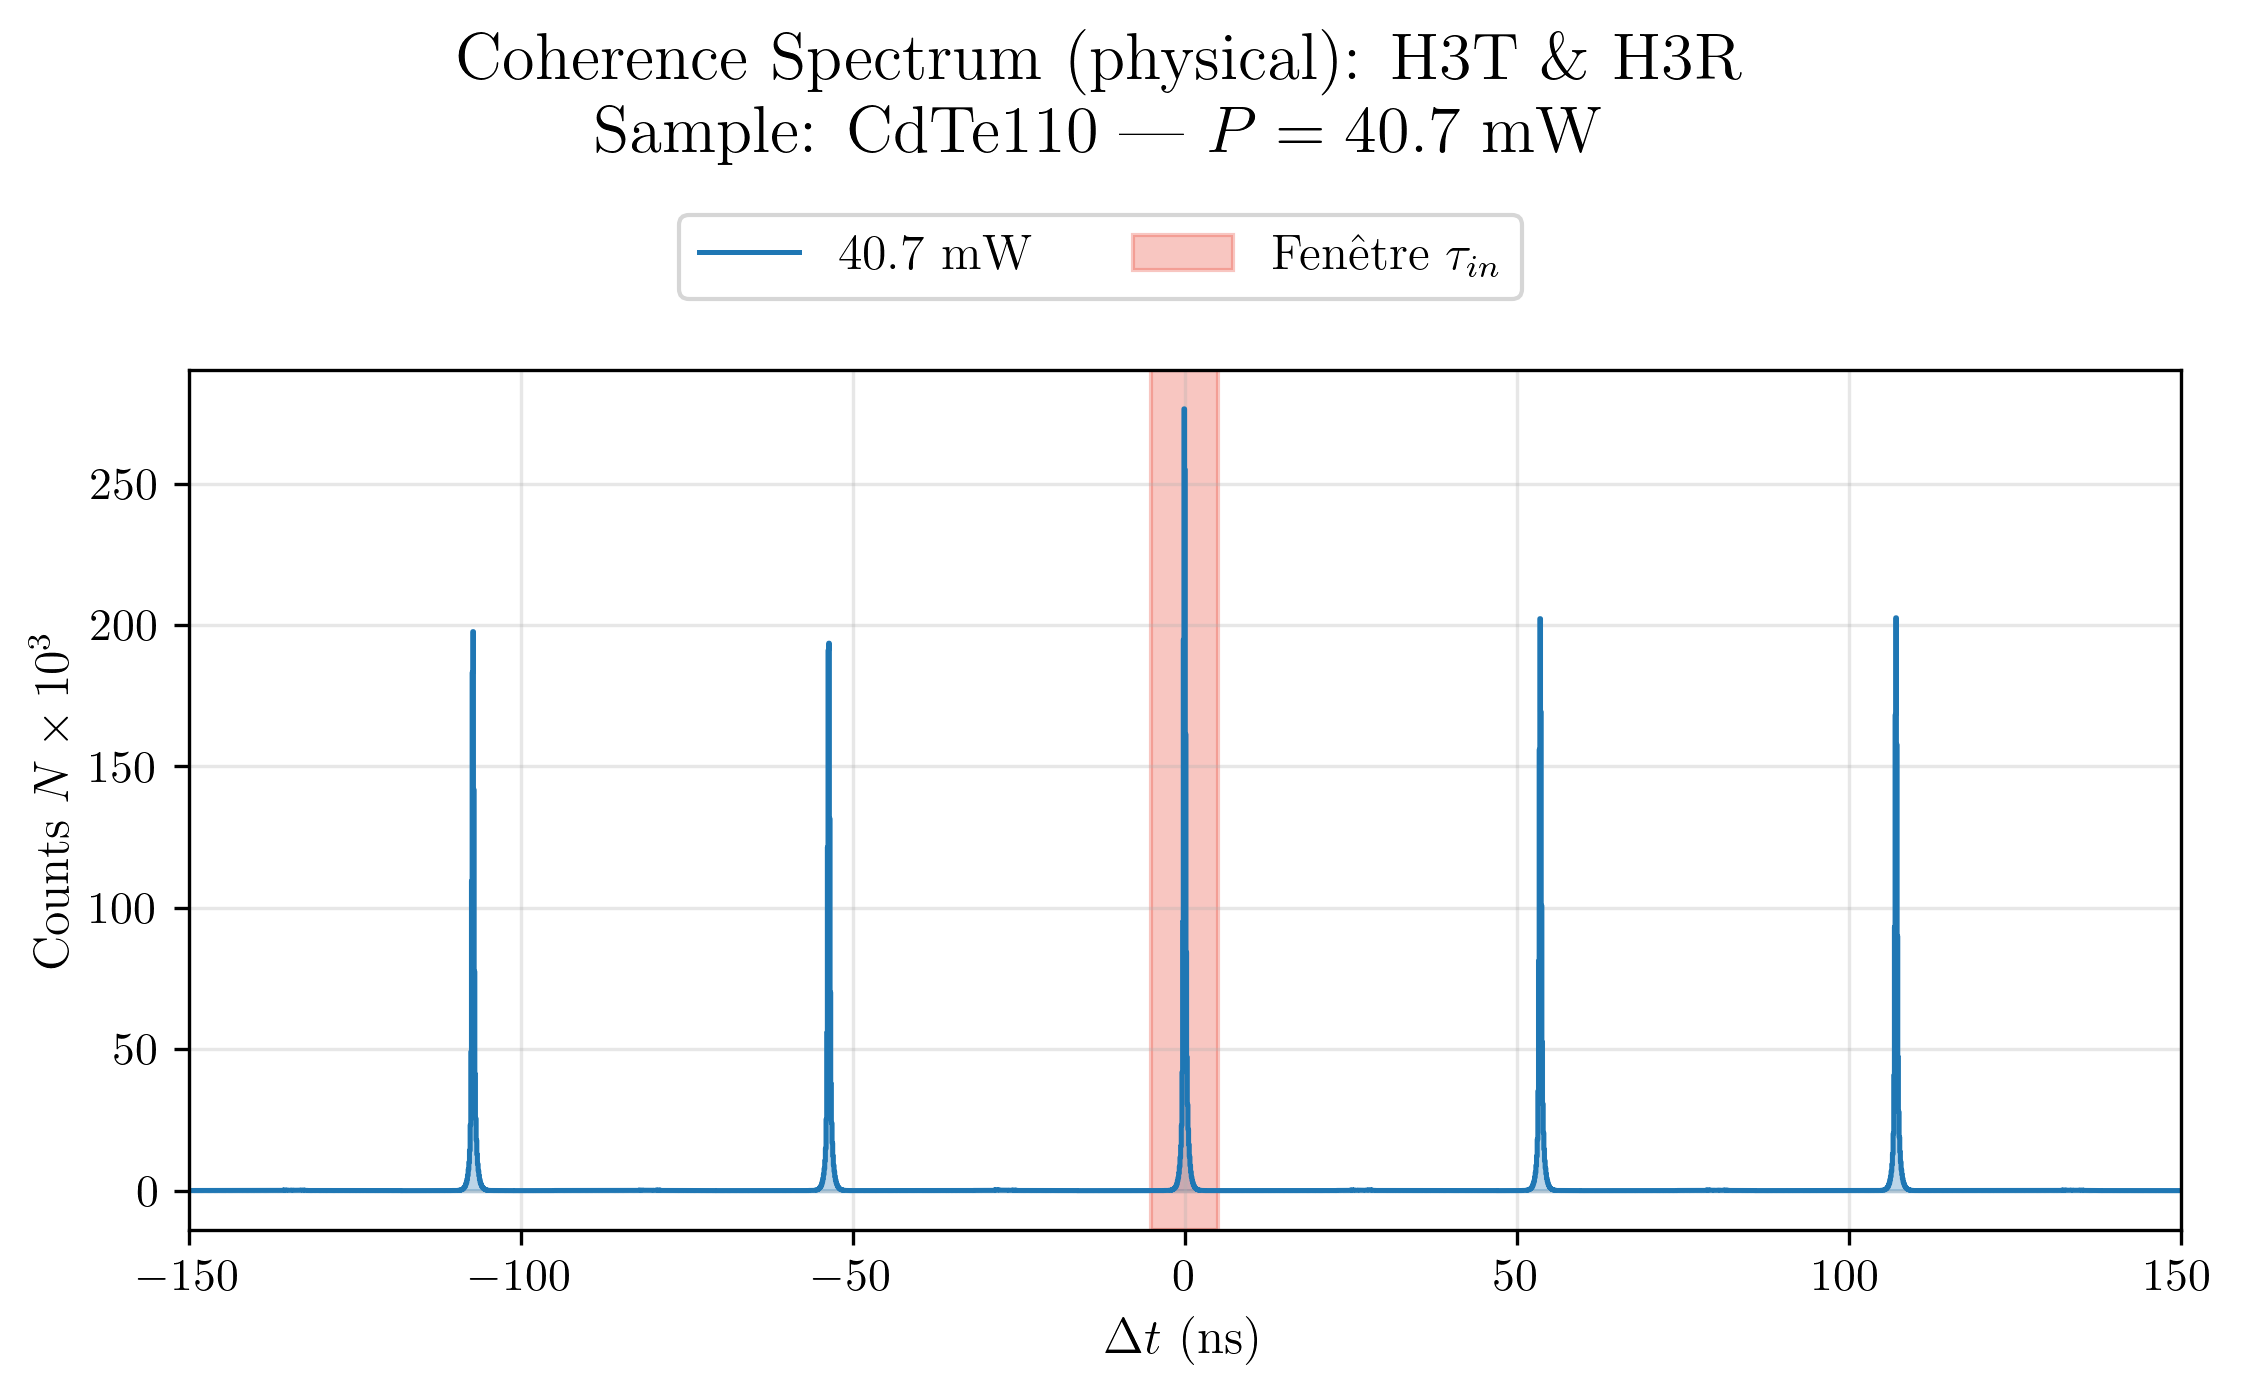

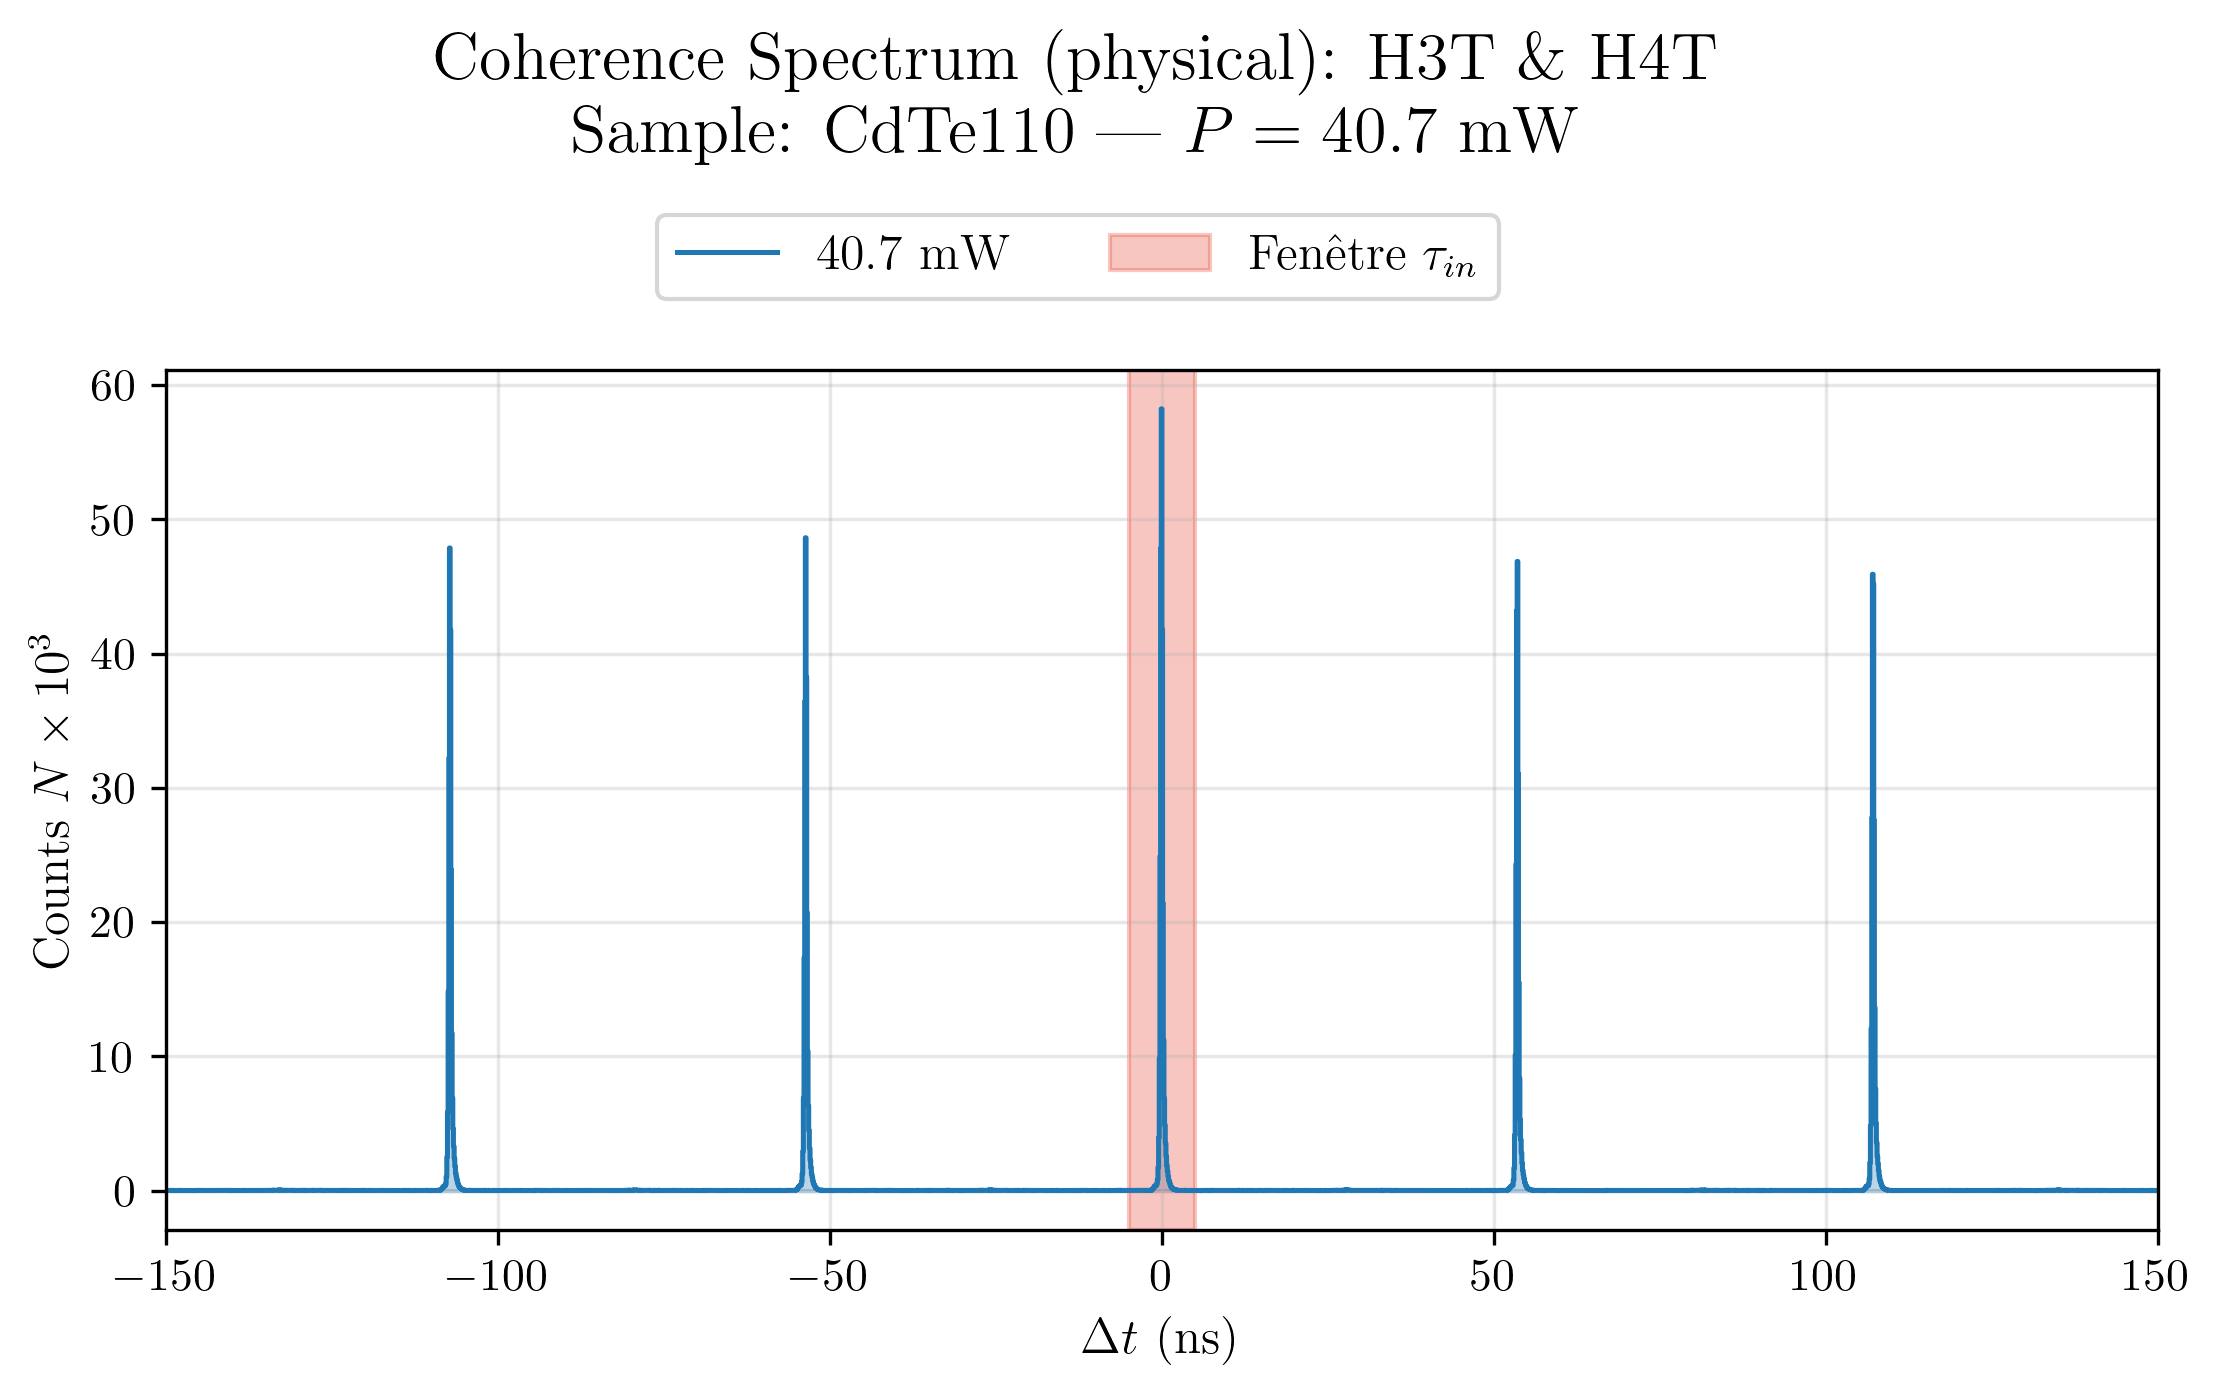

(<Figure size 2400x1500 with 1 Axes>,
 <Axes: xlabel='$\\Delta t$ (ns)', ylabel='Counts $N \\times 10^3$'>)

In [5]:
visu = GridVisualizer(run)
H3T, H3R = run.get_ch("H3T"), run.get_ch("H3R")
H4T, H4R = run.get_ch("H4T"), run.get_ch("H4R")
H5T, H5R = run.get_ch("H5T"), run.get_ch("H5R")

visu.plot_coherence(H3T, H3R, xlim=150, integration_window_ns=10)
visu.plot_coherence(H3T, H4T, xlim=150, integration_window_ns=10)

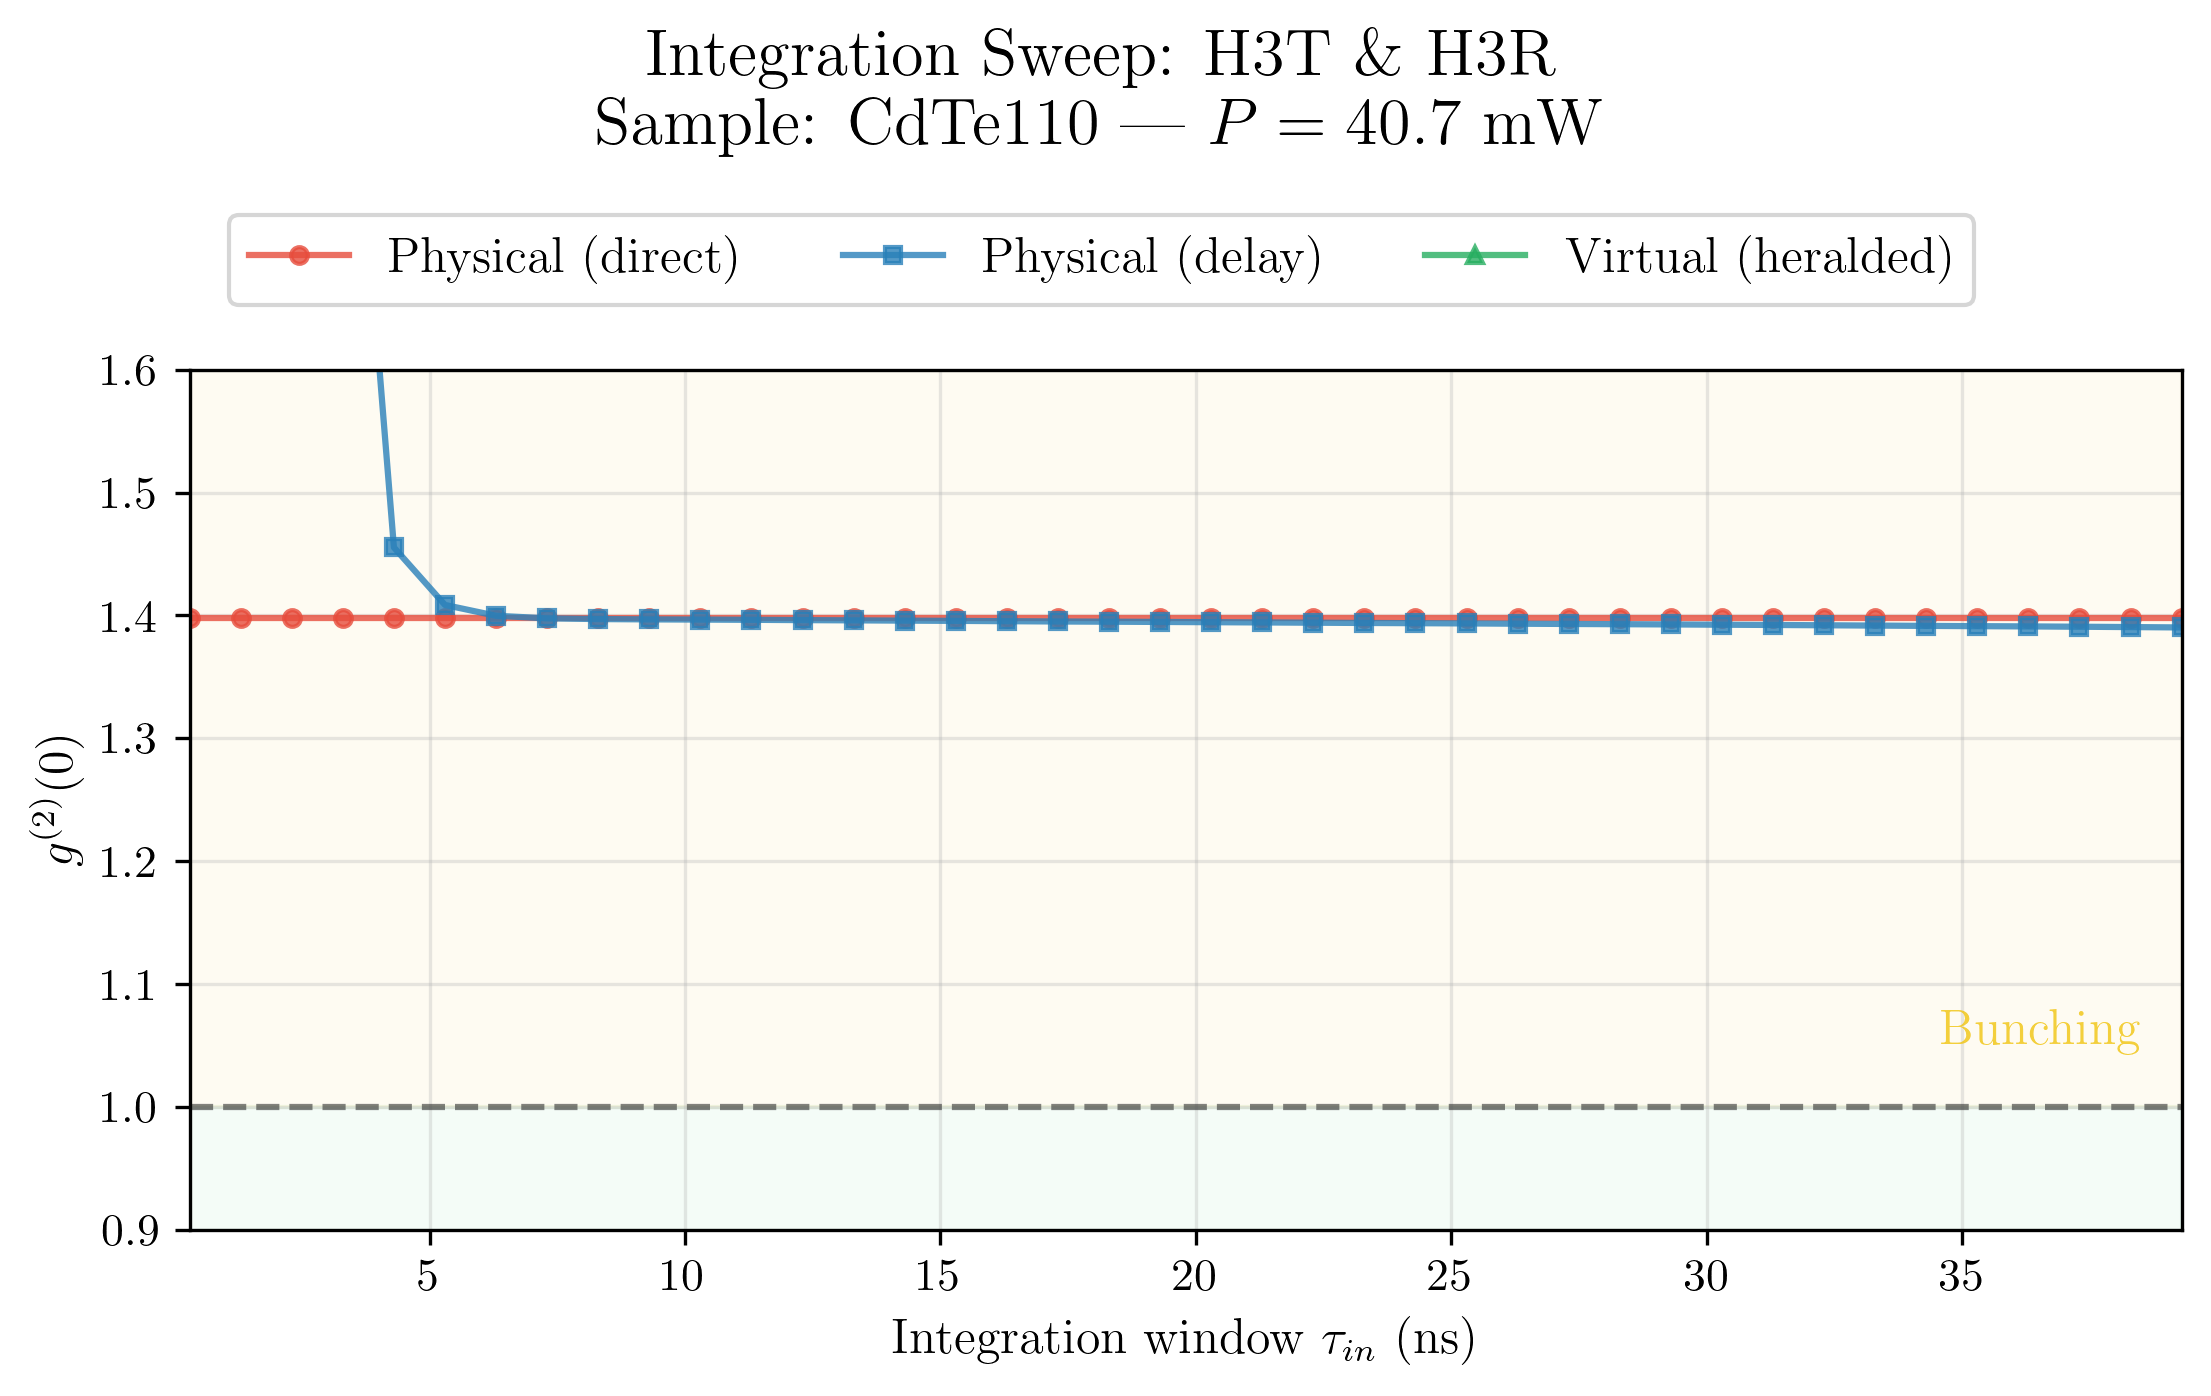

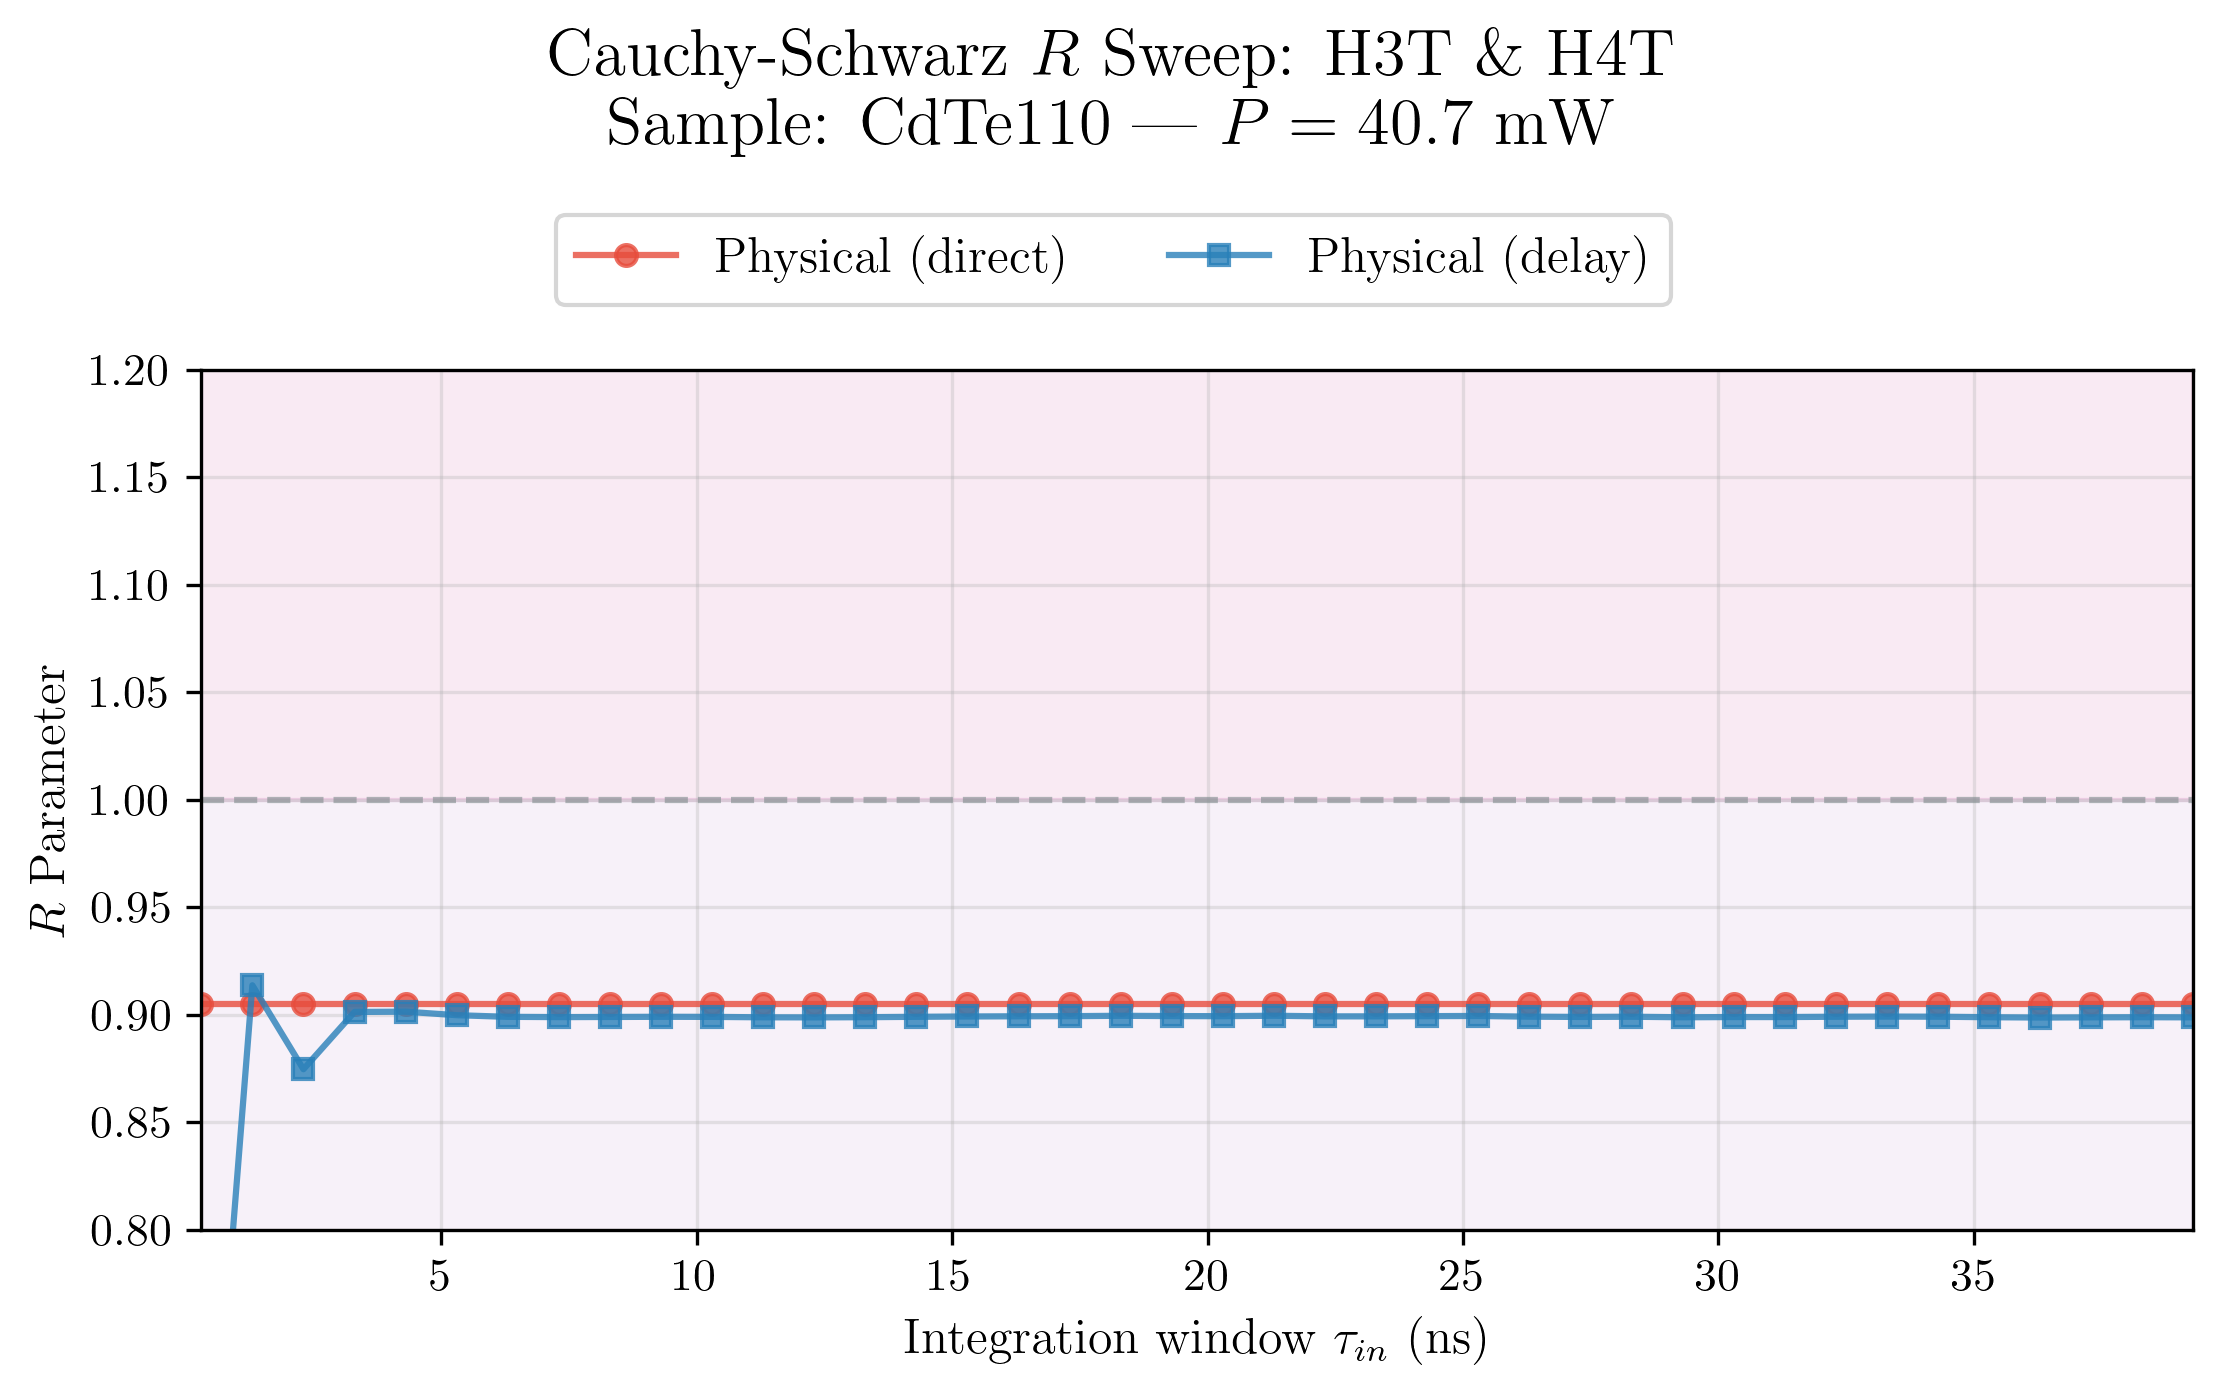

(<Figure size 2400x1500 with 1 Axes>,
 <Axes: xlabel='Integration window $\\tau_{in}$ (ns)', ylabel='$R$ Parameter'>)

In [6]:
visu.plot_g2(H3T, H3R, methods=['direct', 'delay', 'heralded'], tau_min=0.3, tau_max=40, step=1.0)

visu.plot_R(cross_pair=(H3T, H4T), auto_pair_1=(H3T, H3R), auto_pair_2=(H4T, H4R), methods=['direct', 'delay'], tau_min=0.3, tau_max=40, step=1.0)

## 5. Coherence grid (full 5x3 matrix)

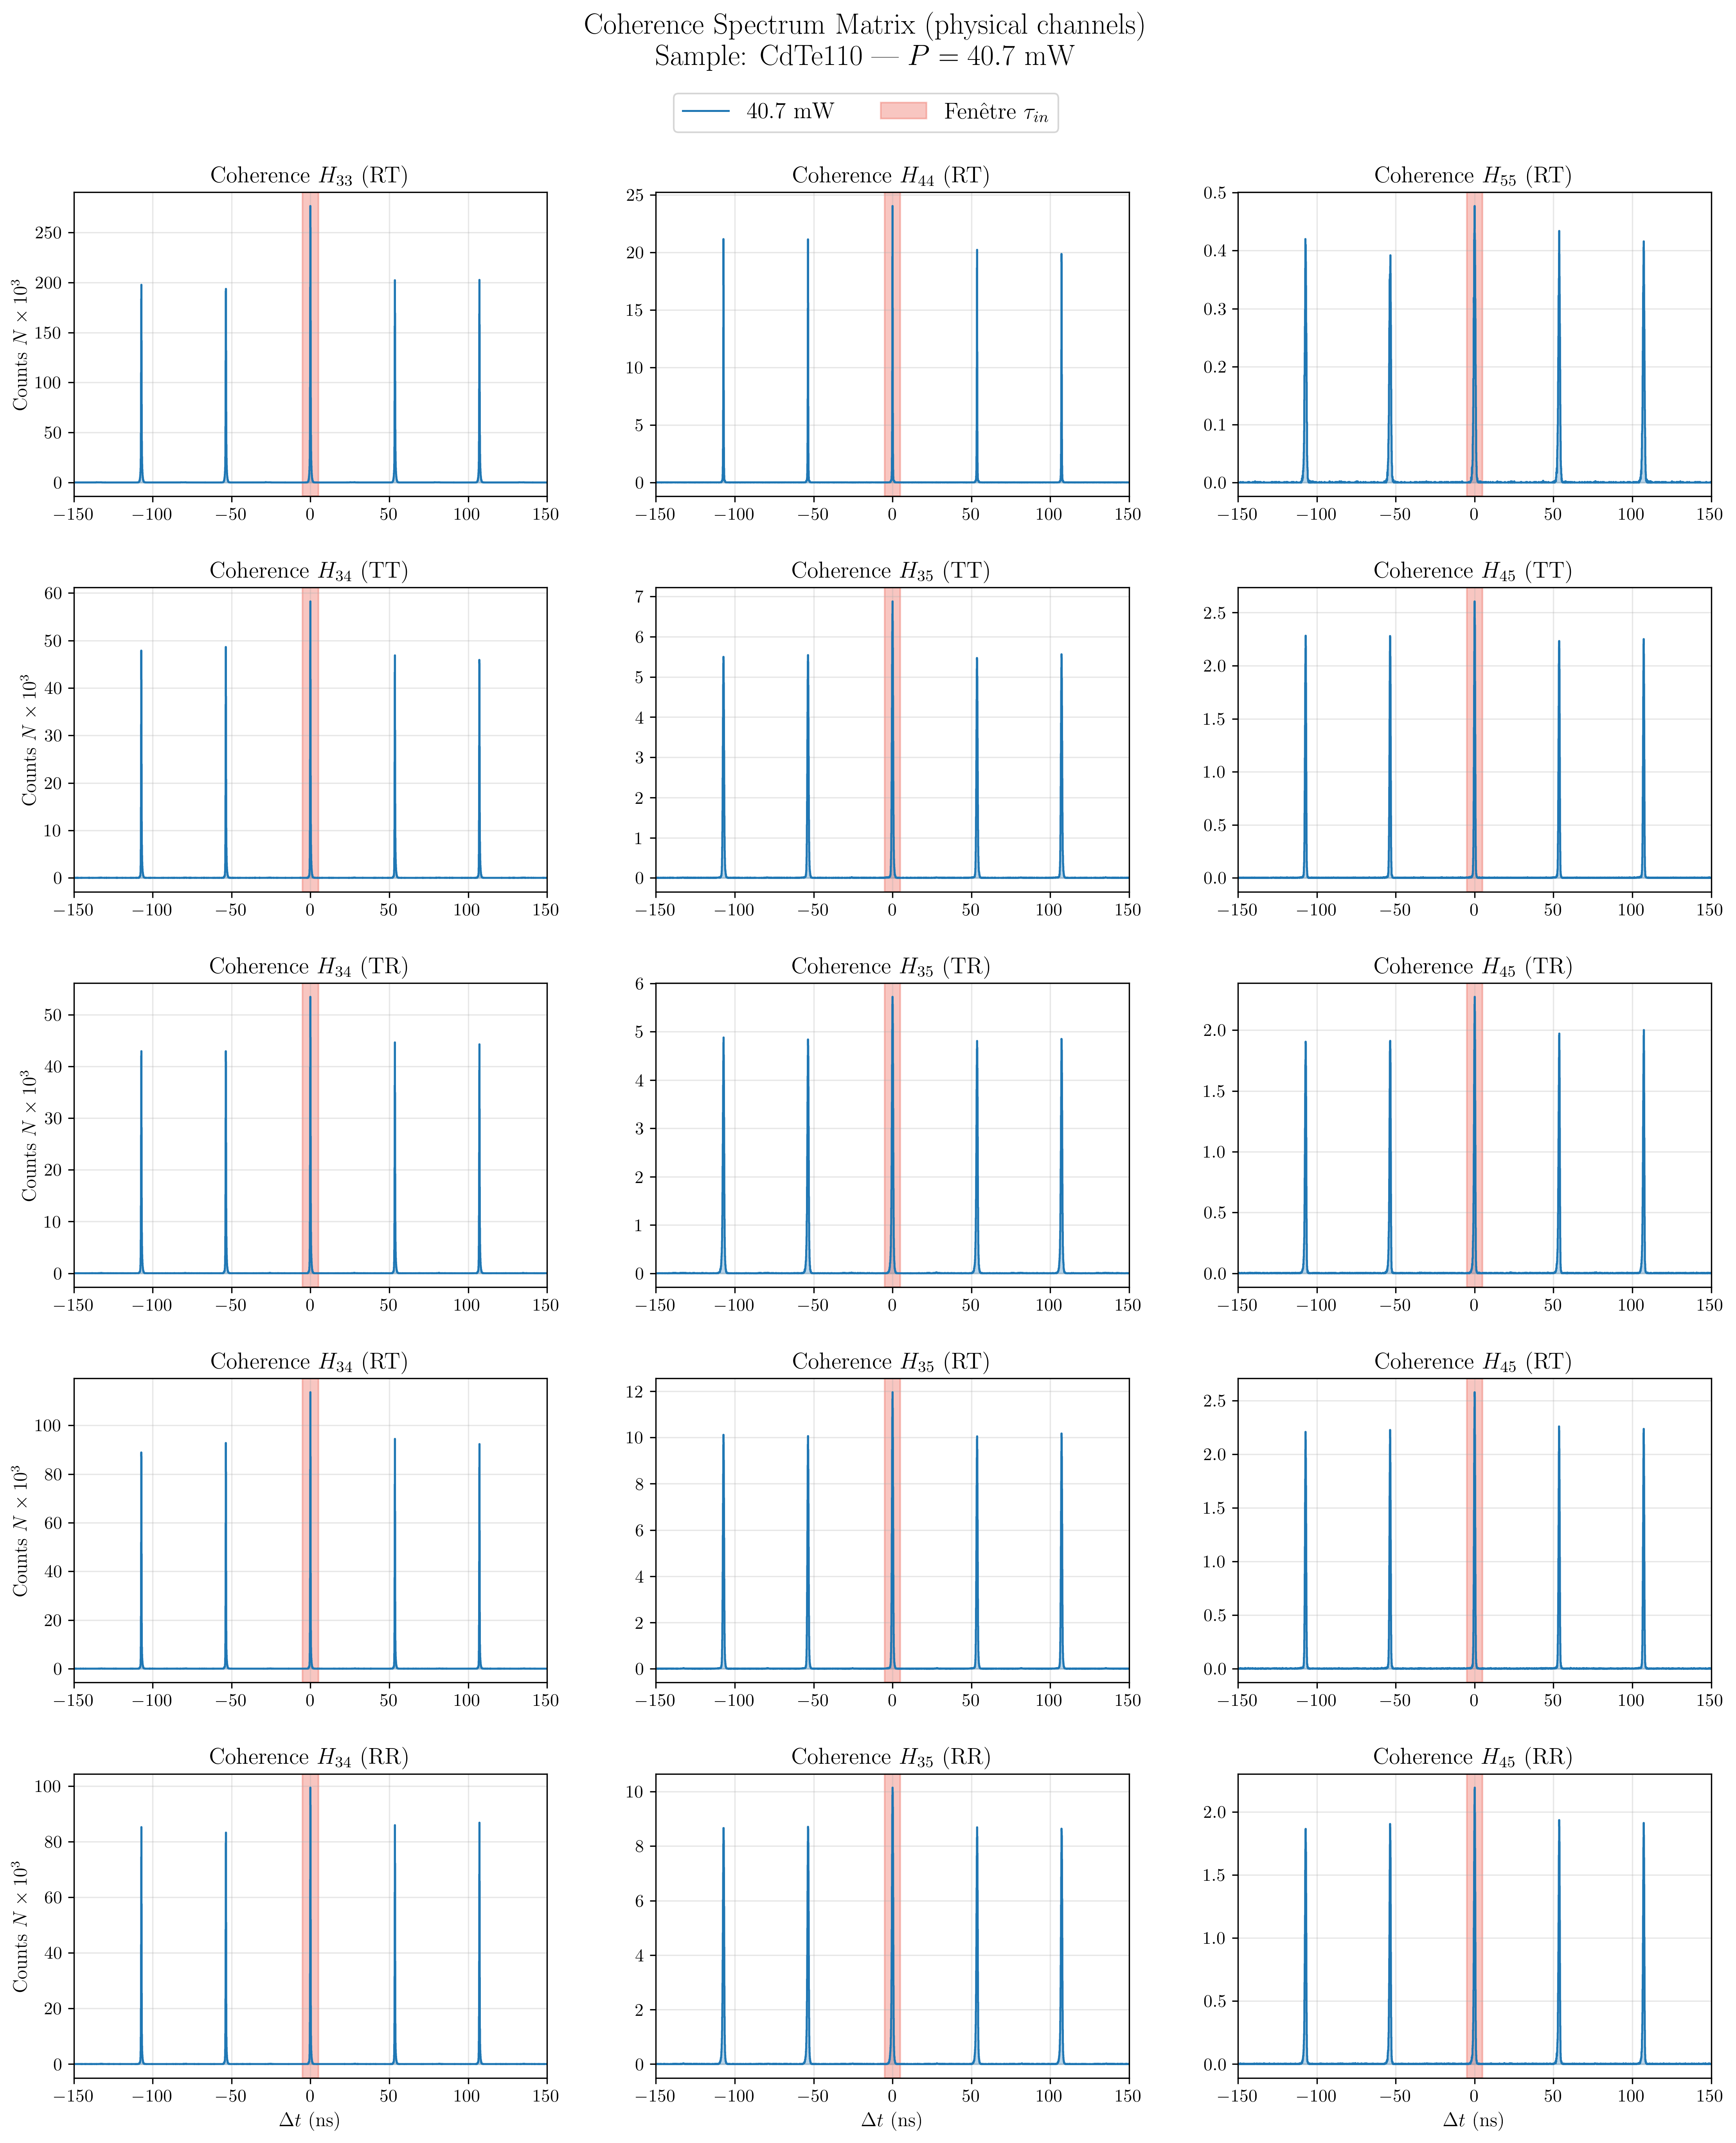

(<Figure size 5400x6000 with 15 Axes>,
 array([[<Axes: title={'center': 'Coherence $H_{33}$ (RT)'}, ylabel='Counts $N \\times 10^3$'>,
         <Axes: title={'center': 'Coherence $H_{44}$ (RT)'}>,
         <Axes: title={'center': 'Coherence $H_{55}$ (RT)'}>],
        [<Axes: title={'center': 'Coherence $H_{34}$ (TT)'}, ylabel='Counts $N \\times 10^3$'>,
         <Axes: title={'center': 'Coherence $H_{35}$ (TT)'}>,
         <Axes: title={'center': 'Coherence $H_{45}$ (TT)'}>],
        [<Axes: title={'center': 'Coherence $H_{34}$ (TR)'}, ylabel='Counts $N \\times 10^3$'>,
         <Axes: title={'center': 'Coherence $H_{35}$ (TR)'}>,
         <Axes: title={'center': 'Coherence $H_{45}$ (TR)'}>],
        [<Axes: title={'center': 'Coherence $H_{34}$ (RT)'}, ylabel='Counts $N \\times 10^3$'>,
         <Axes: title={'center': 'Coherence $H_{35}$ (RT)'}>,
         <Axes: title={'center': 'Coherence $H_{45}$ (RT)'}>],
        [<Axes: title={'center': 'Coherence $H_{34}$ (RR)'}, xlabel='$\\Delta

In [7]:
visu.plot_coherence(time_window_ns=5, xlim=150, integration_window_ns=10)

## 6. $g^{(2)}$ grids

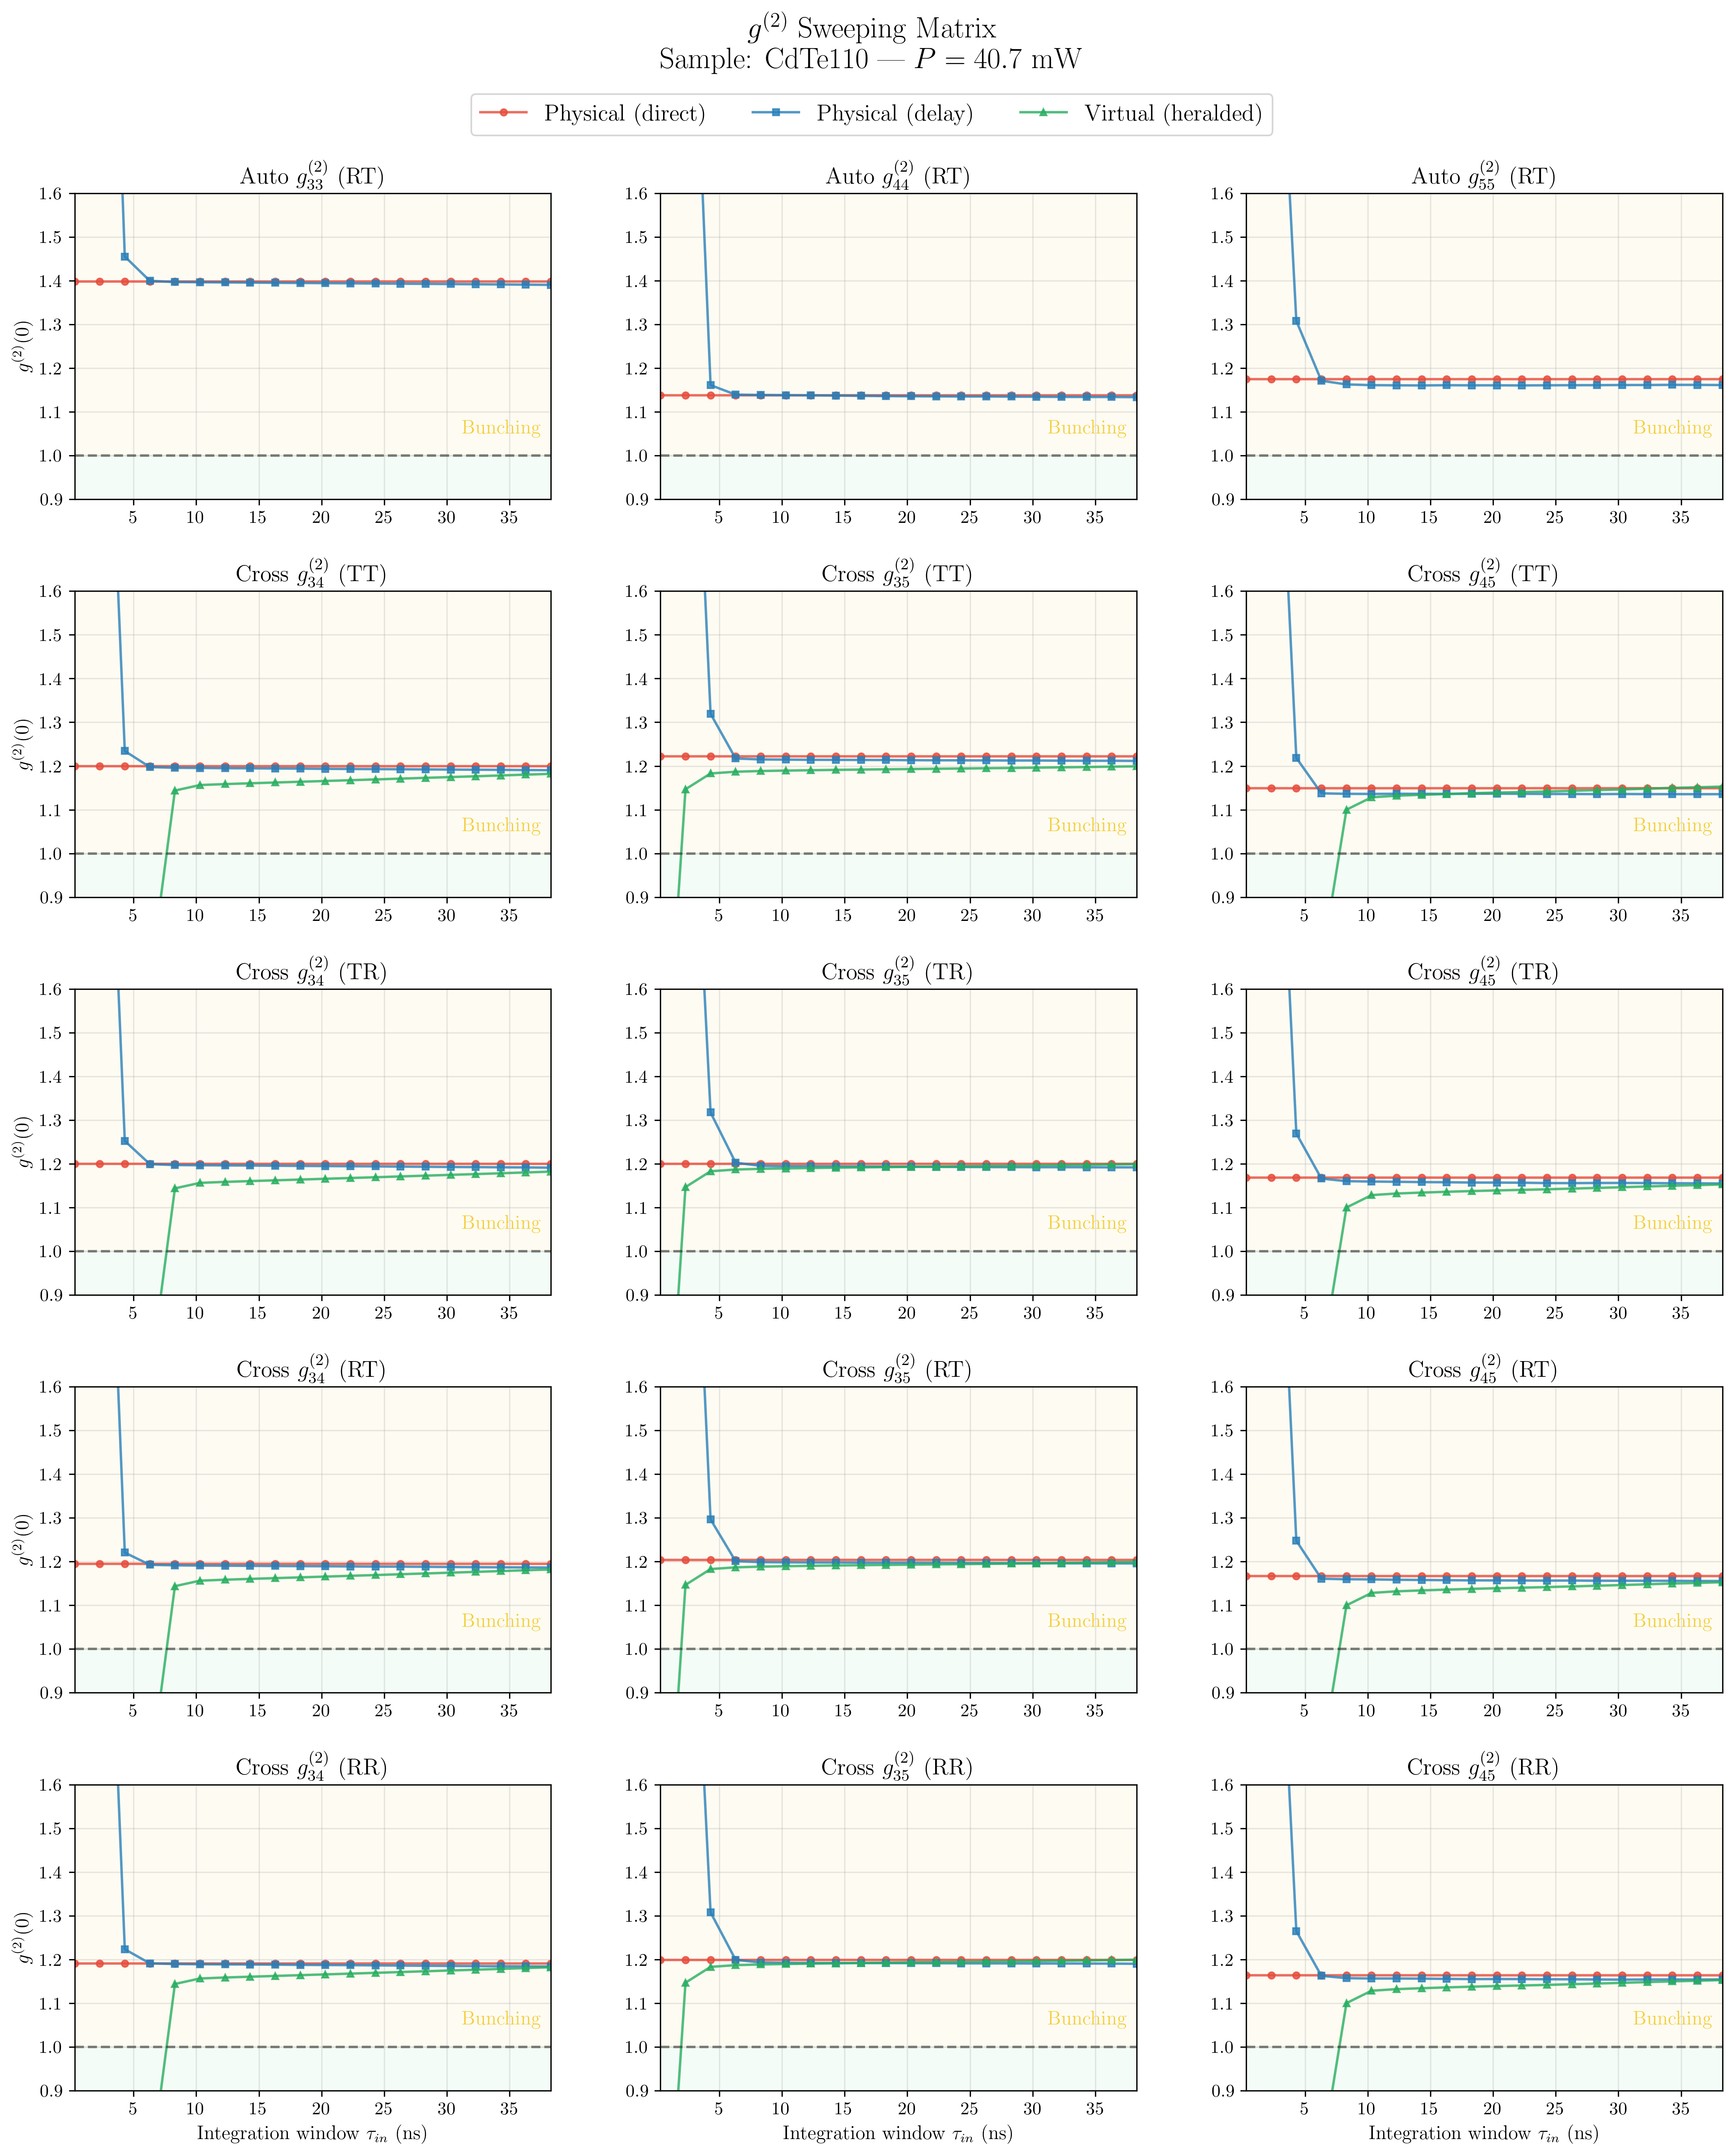

(<Figure size 5400x6000 with 15 Axes>,
 array([[<Axes: title={'center': 'Auto $g^{(2)}_{33}$ (RT)'}, ylabel='$g^{(2)}(0)$'>,
         <Axes: title={'center': 'Auto $g^{(2)}_{44}$ (RT)'}>,
         <Axes: title={'center': 'Auto $g^{(2)}_{55}$ (RT)'}>],
        [<Axes: title={'center': 'Cross $g^{(2)}_{34}$ (TT)'}, ylabel='$g^{(2)}(0)$'>,
         <Axes: title={'center': 'Cross $g^{(2)}_{35}$ (TT)'}>,
         <Axes: title={'center': 'Cross $g^{(2)}_{45}$ (TT)'}>],
        [<Axes: title={'center': 'Cross $g^{(2)}_{34}$ (TR)'}, ylabel='$g^{(2)}(0)$'>,
         <Axes: title={'center': 'Cross $g^{(2)}_{35}$ (TR)'}>,
         <Axes: title={'center': 'Cross $g^{(2)}_{45}$ (TR)'}>],
        [<Axes: title={'center': 'Cross $g^{(2)}_{34}$ (RT)'}, ylabel='$g^{(2)}(0)$'>,
         <Axes: title={'center': 'Cross $g^{(2)}_{35}$ (RT)'}>,
         <Axes: title={'center': 'Cross $g^{(2)}_{45}$ (RT)'}>],
        [<Axes: title={'center': 'Cross $g^{(2)}_{34}$ (RR)'}, xlabel='Integration window $\\tau_{in

In [8]:
visu.plot_g2(methods=['direct', 'delay', 'heralded'], tau_min=0.3, tau_max=40, step=2.0)

## 7. Cauchy–Schwarz $R$ grids

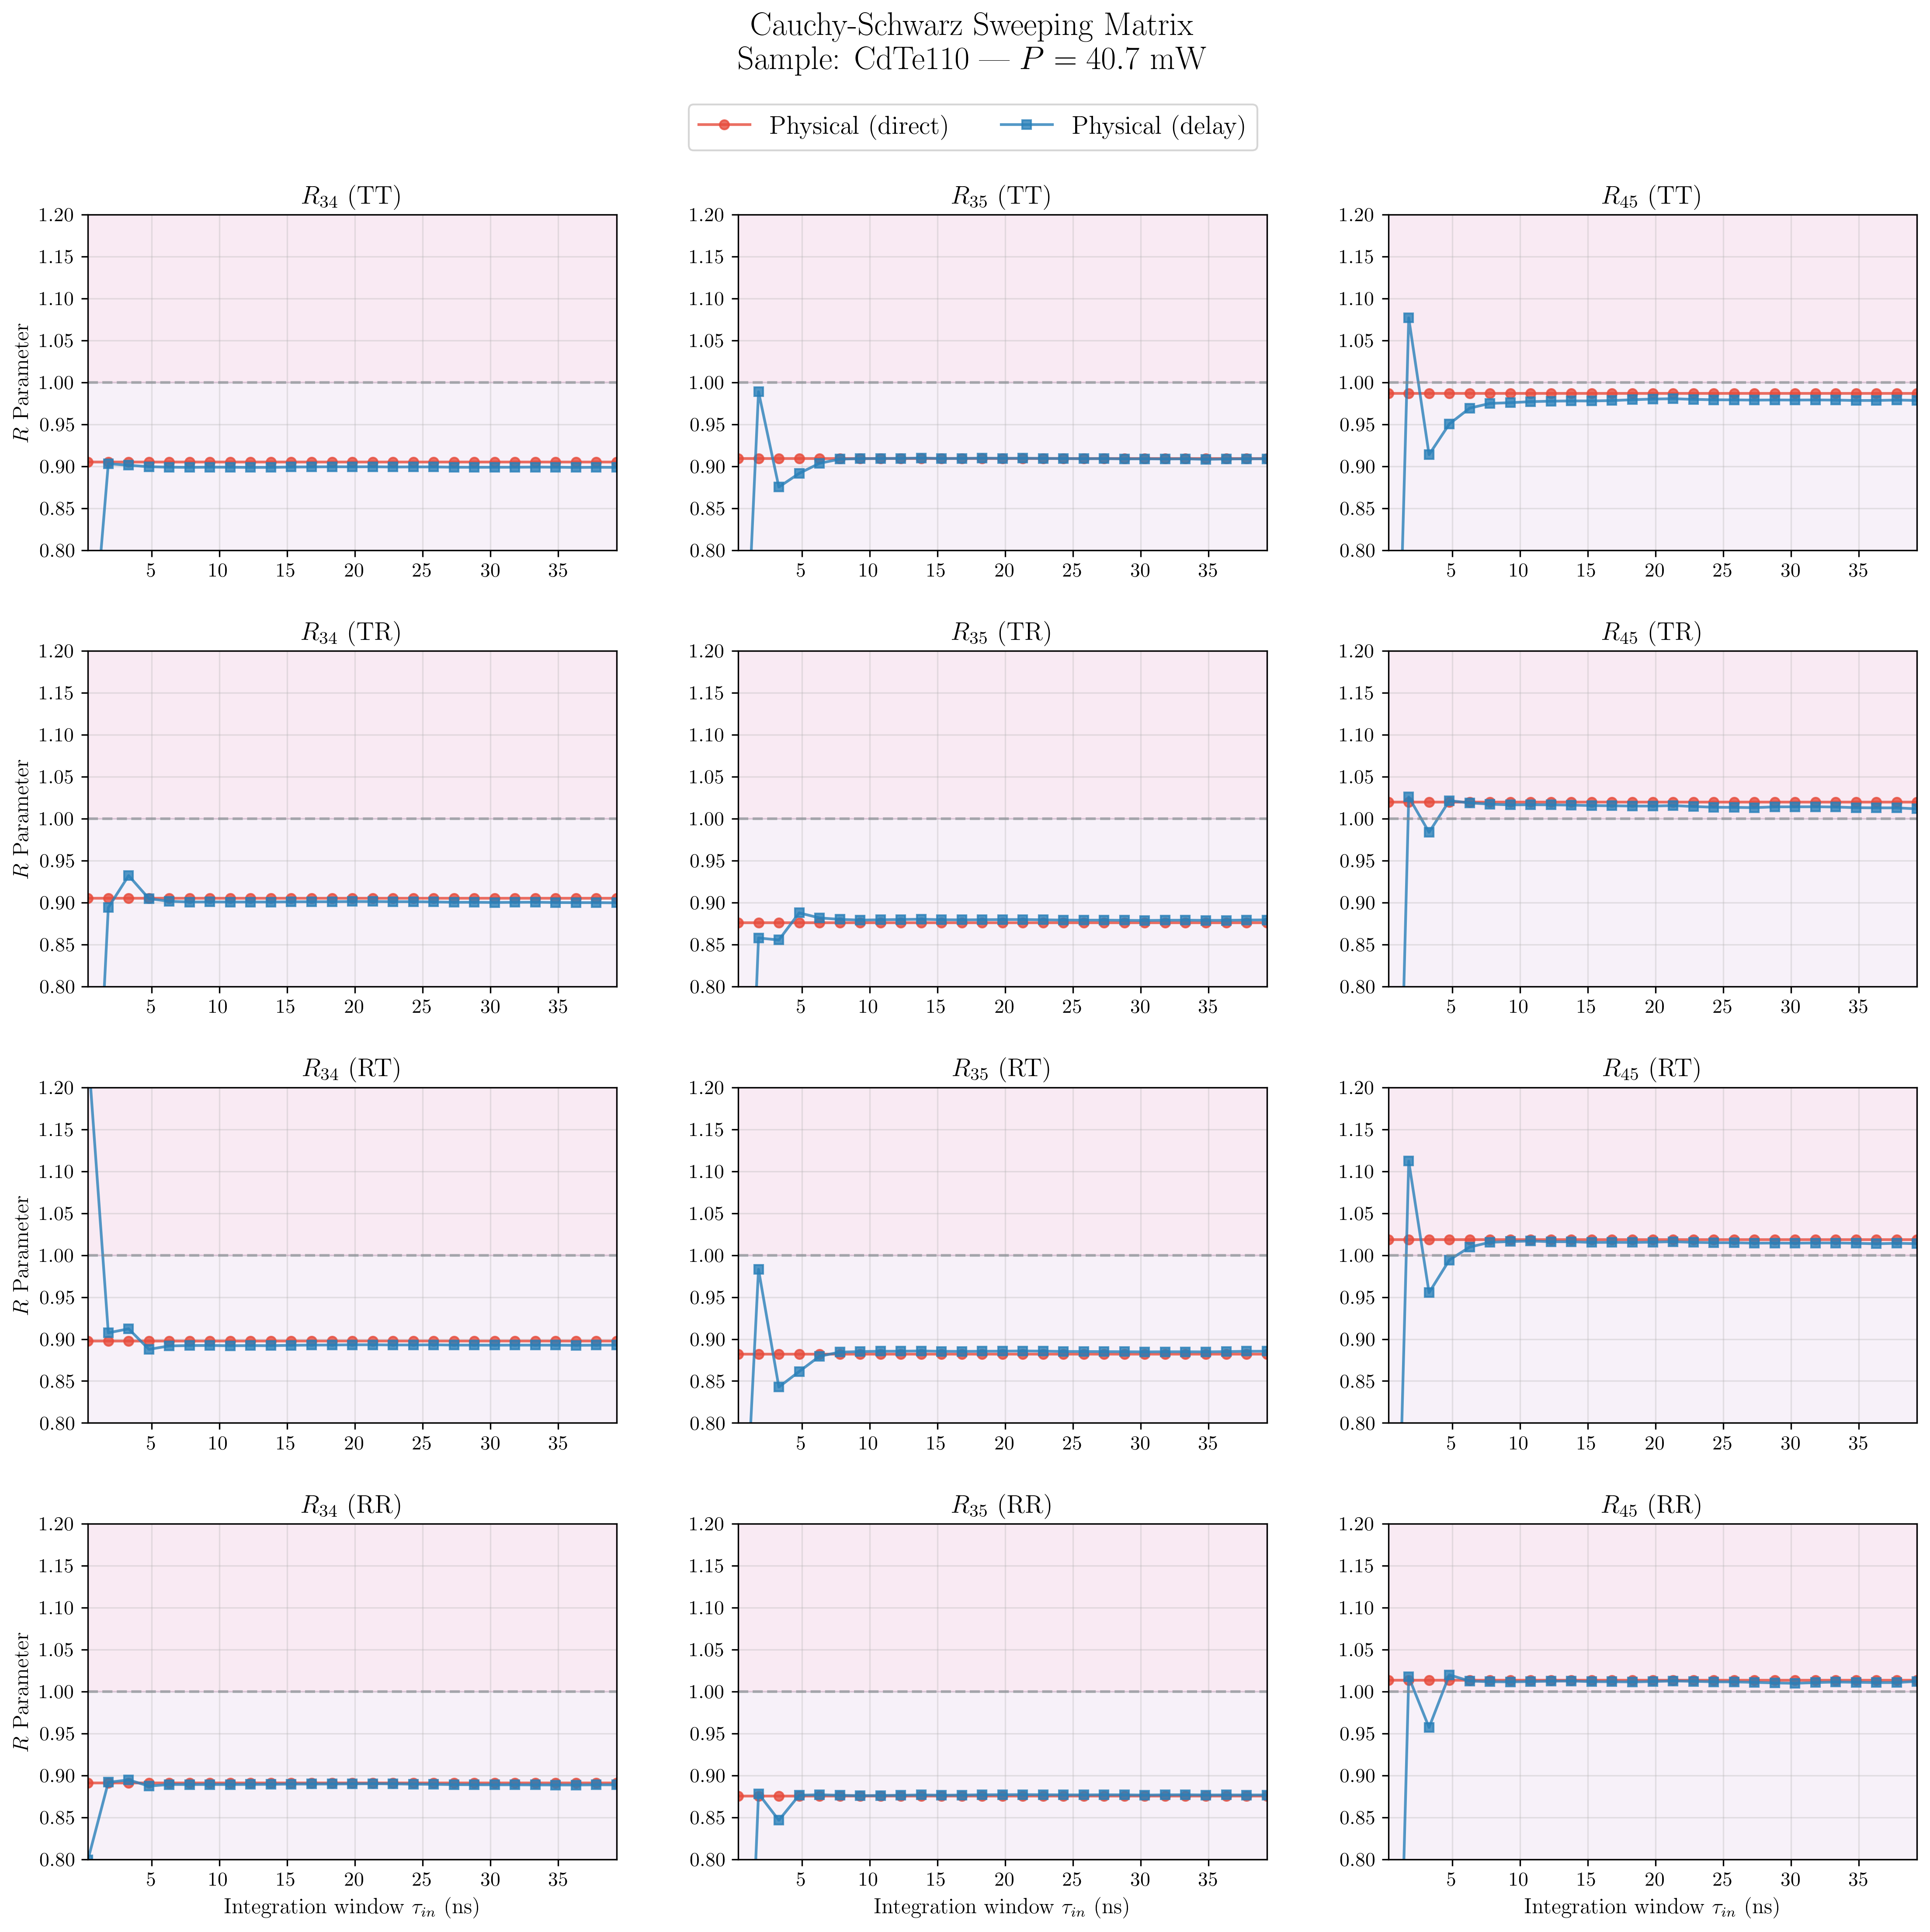

(<Figure size 5400x4800 with 12 Axes>,
 array([[<Axes: title={'center': '$R_{34}$ (TT)'}, ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (TT)'}>,
         <Axes: title={'center': '$R_{45}$ (TT)'}>],
        [<Axes: title={'center': '$R_{34}$ (TR)'}, ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (TR)'}>,
         <Axes: title={'center': '$R_{45}$ (TR)'}>],
        [<Axes: title={'center': '$R_{34}$ (RT)'}, ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (RT)'}>,
         <Axes: title={'center': '$R_{45}$ (RT)'}>],
        [<Axes: title={'center': '$R_{34}$ (RR)'}, xlabel='Integration window $\\tau_{in}$ (ns)', ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (RR)'}, xlabel='Integration window $\\tau_{in}$ (ns)'>,
         <Axes: title={'center': '$R_{45}$ (RR)'}, xlabel='Integration window $\\tau_{in}$ (ns)'>]],
       dtype=object))

In [11]:
visu.plot_R(methods=['direct', 'delay'], tau_min=0.3, tau_max=40, step=1.5)